# 🏃 Chương 4 — Dataset 4: HAR Sensor Data — GRU Time Series
## Kỹ thuật: Human Activity Recognition + Bidirectional GRU + Sensor Visualization

**Pipeline:** EDA → Sensor Signal Analysis → Sliding Window → BiGRU → Train → Per-Class Evaluation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import glob, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR    = '../data/har'
SAVE_DIR    = '../results/har_gru'
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS      = 25
BATCH_SIZE  = 64

print(f'TF: {tf.__version__}')

I0000 00:00:1780120538.418570 2027579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780120538.454202 2027579 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0


I0000 00:00:1780120539.225422 2027579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 📂 1. Load HAR Dataset

In [2]:
train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

df_train.head(5)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
label_col = 'Activity'

feature_cols = [c for c in df_train.columns if c != label_col and df_train[c].dtype != object]

le = LabelEncoder()
y_train_raw = le.fit_transform(df_train[label_col])
y_test_raw = le.transform(df_test[label_col])

X_train_raw = df_train[feature_cols].values
X_test_raw = df_test[feature_cols].values

CLASSES = le.classes_.tolist()
NUM_CLASSES = len(CLASSES)

print("\nData loaded successfully!")
print(f" - Train shape: {X_train_raw.shape}, Train labels: {y_train_raw.shape}")
print(f" - Test shape:  {X_test_raw.shape}, Test labels:  {y_test_raw.shape}")
print(f" - Number of classes: {NUM_CLASSES}")
print(f" - Classes list:      {CLASSES}")


Data loaded successfully!
 - Train shape: (7352, 562), Train labels: (7352,)
 - Test shape:  (2947, 562), Test labels:  (2947,)
 - Number of classes: 6
 - Classes list:      ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


## 📊 2. EDA — Sensor Signal Analysis

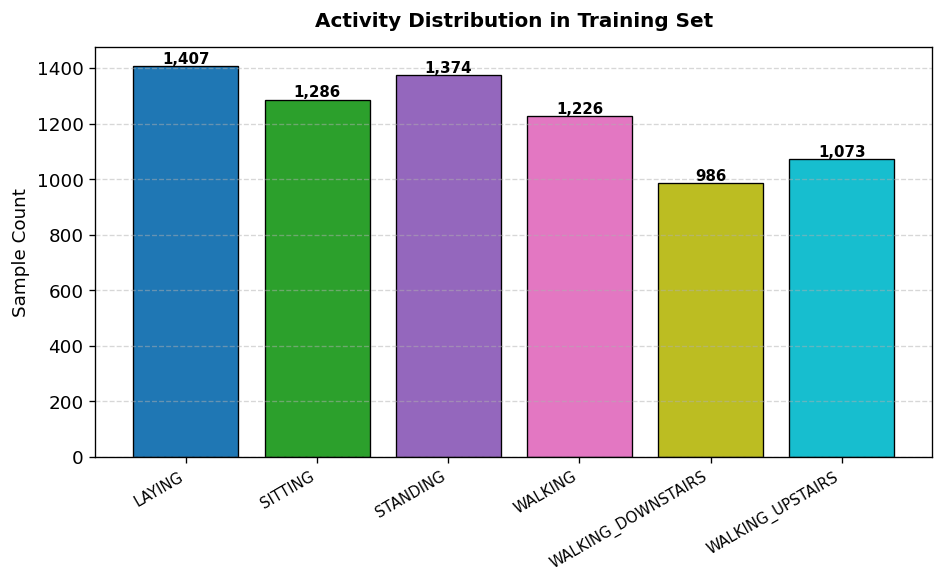

In [4]:
# 1. Class Distribution Bar Chart
unique_labels, counts = np.unique(y_train_raw, return_counts=True)
class_labels = [CLASSES[i] if i < len(CLASSES) else f'Class {i}' for i in unique_labels]

plt.figure(figsize=(8, 5))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
bars = plt.bar(class_labels, counts, color=colors, edgecolor='black', linewidth=0.8)

plt.title('Activity Distribution in Training Set', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Sample Count')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_a_class_distribution_bar.png', dpi=120, bbox_inches='tight')
plt.show()

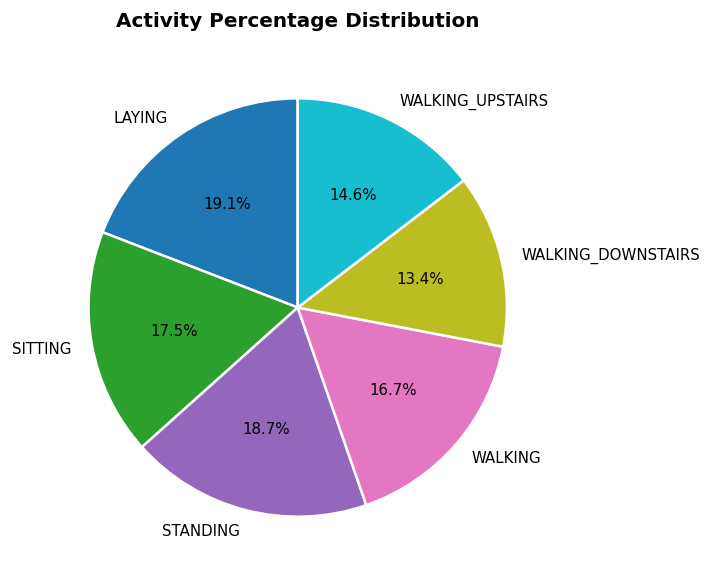

In [5]:
# 2. Class Percentage Pie Chart
plt.figure(figsize=(6, 6))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
plt.pie(counts, labels=class_labels, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops={'fontsize': 9})

plt.title('Activity Percentage Distribution', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()

plt.savefig(f'{SAVE_DIR}/01_b_class_distribution_pie.png', dpi=120, bbox_inches='tight')
plt.show()

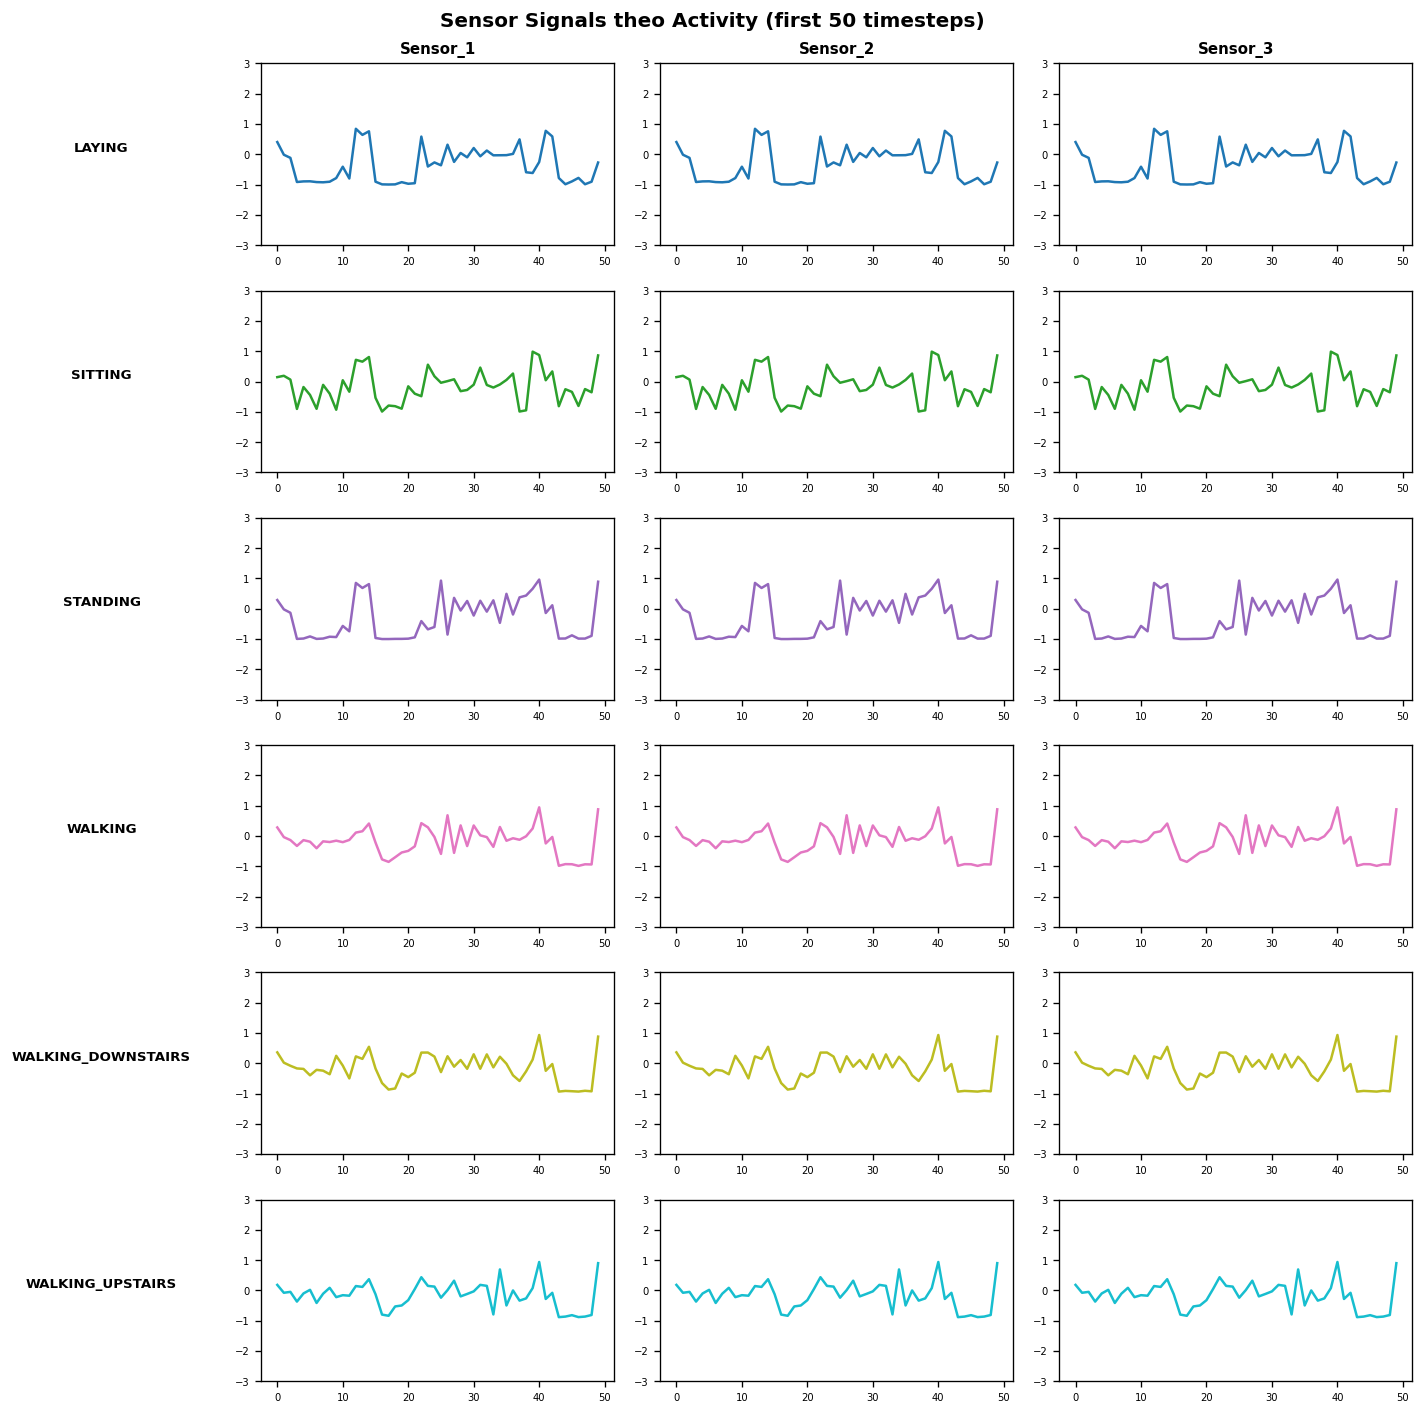

In [6]:
# Sensor signal comparison per activity
# Use first 3 features as proxy for accelerometer axes
n_features_display = min(3, X_train_raw.shape[1])
feature_names = [f'Sensor_{i+1}' for i in range(n_features_display)]

fig, axes = plt.subplots(NUM_CLASSES, n_features_display,
                          figsize=(4*n_features_display, 2*NUM_CLASSES))

for r, lbl in enumerate(unique_labels):
    idx = np.where(y_train_raw == lbl)[0][:1][0]
    label_name = CLASSES[lbl] if lbl < len(CLASSES) else f'Class {lbl}'
    for c in range(n_features_display):
        signal = X_train_raw[idx, :]
        axes[r, c].plot(signal[:min(50, len(signal))],
                         color=colors[r], lw=1.5)
        axes[r, c].set_ylim(-3, 3)
        if c == 0:
            axes[r, c].set_ylabel(label_name, rotation=0, labelpad=80,
                                   fontsize=8, fontweight='bold')
        if r == 0:
            axes[r, c].set_title(feature_names[c], fontsize=9)
        axes[r, c].tick_params(labelsize=6)

plt.suptitle('Sensor Signals theo Activity (first 50 timesteps)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sensor_signals.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_raw)
X_test_s  = scaler.transform(X_test_raw)

# Reshape for LSTM: (samples, timesteps, features)
# If flat features, treat each feature as a timestep
X_train_3d = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_test_3d  = X_test_s.reshape(X_test_s.shape[0],  X_test_s.shape[1],  1)

print(f'Input shape: {X_train_3d.shape} -> (samples, features, 1)')
print(f'Labels: {y_train_raw.shape}')

Input shape: (7352, 562, 1) -> (samples, features, 1)
Labels: (7352,)


## 🏗️ 4. Bidirectional GRU Model

In [8]:
input_shape = X_train_3d.shape[1:]

model = models.Sequential([
    layers.Bidirectional(
        layers.GRU(128, return_sequences=True),
        input_shape=input_shape,
        name='bigru_1'
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Bidirectional(
        layers.GRU(64, return_sequences=False),
        name='bigru_2'
    ),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiGRU_HAR')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1780120548.090002 2027579 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 910 MB memory:  -> device: 0, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780120548.091702 2027579 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46288 MB memory:  -> device: 1, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1780120548.093331 2027579 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 1520 MB memory:  -> device: 2, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:83:00.0, compute capability: 8.9


Model: "BiGRU_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bigru_1 (Bidirectional)         │ (None, 562, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 562, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 562, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,926 (913.77 KB)

 Trainable params: 233,414 (911.77 KB)

 Non-trainable params: 512 (2.00 KB)

## 🚀 5. Training

In [9]:
history = model.fit(
    X_train_3d, y_train_raw,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

Epoch 1/25


I0000 00:00:1780120551.632277 2028716 cuda_dnn.cc:461] Loaded cuDNN version 92101


104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6628 - loss: 0.7862 - val_accuracy: 0.7242 - val_loss: 0.9991 - learning_rate: 0.0010
Epoch 2/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7999 - loss: 0.4831 - val_accuracy: 0.8533 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 3/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8342 - loss: 0.4102 - val_accuracy: 0.8478 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 4/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8570 - loss: 0.3560 - val_accuracy: 0.8465 - val_loss: 0.3281 - learning_rate: 0.0010
Epoch 5/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8794 - loss: 0.3033 - val_accuracy: 0.8519 - val_loss: 0.3384 - learning_rate: 0.0010
Epoch 6/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8919 - loss: 0.2729 - val_accuracy: 0.8302 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 7/25
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8992 - loss: 0.2657
Epoch

## 📈 6. Evaluation

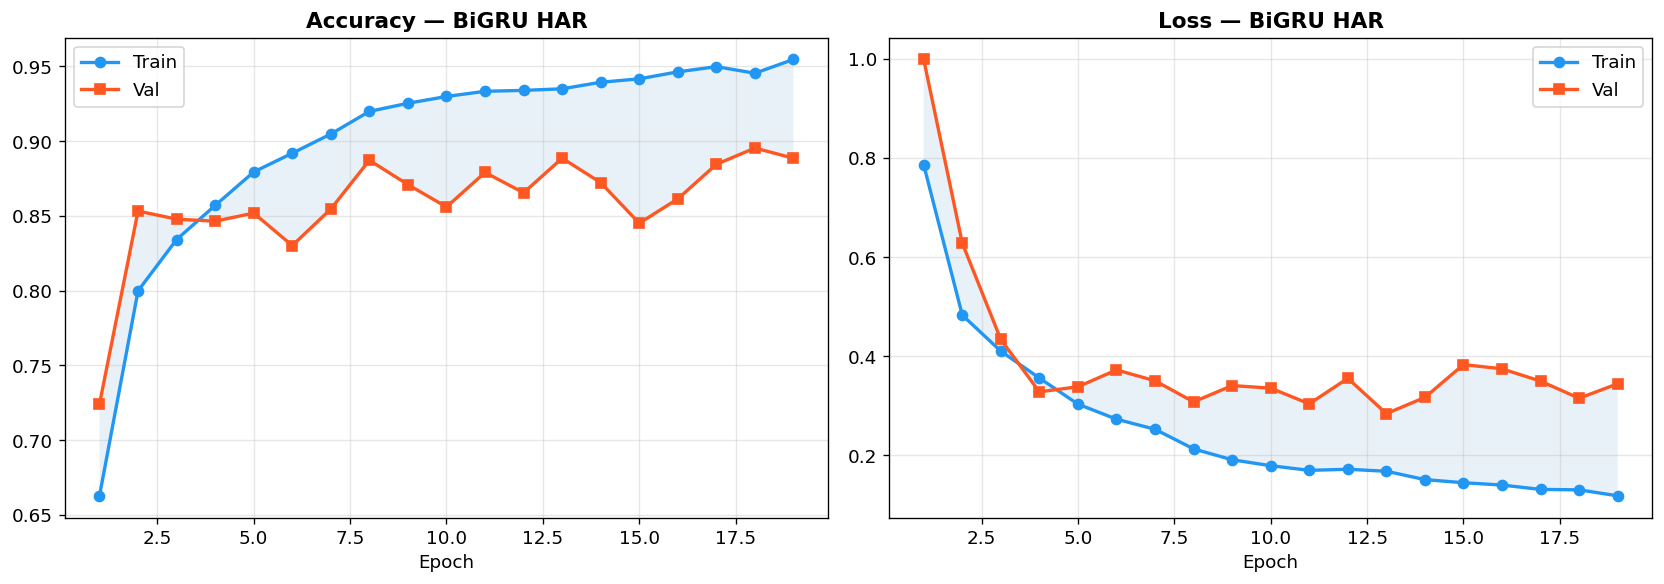

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} — BiGRU HAR')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

In [11]:
y_pred_prob = model.predict(X_test_3d, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test_raw

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

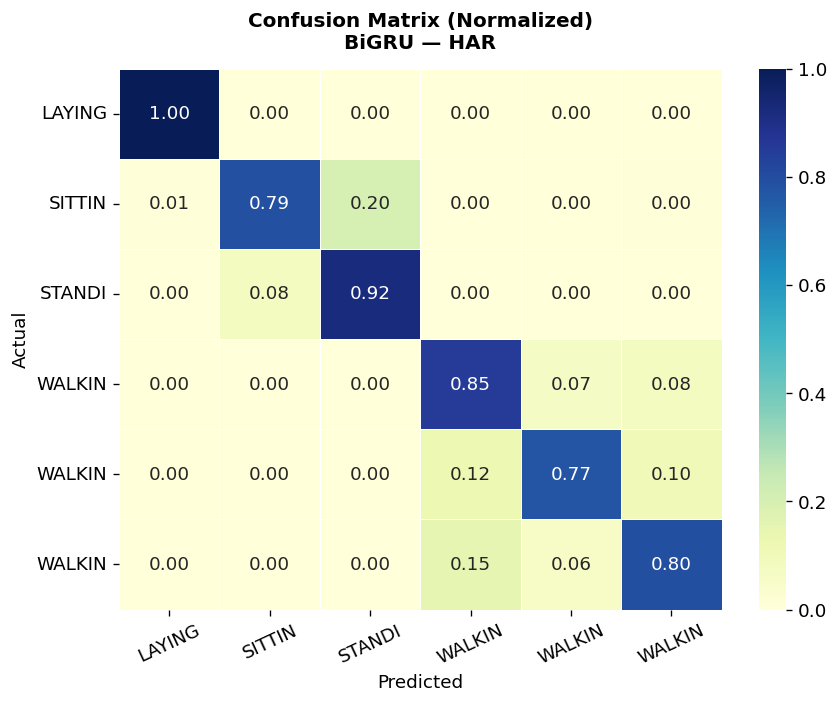

In [12]:
# 1. Confusion Matrix (Normalized)
plt.figure(figsize=(7.5, 6))

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[c[:6] for c in class_labels],
            yticklabels=[c[:6] for c in class_labels],
            linewidths=0.5)

plt.title('Confusion Matrix (Normalized)\nBiGRU — HAR', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()

# Lưu biểu đồ Confusion Matrix
plt.savefig(f'{SAVE_DIR}/04_a_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

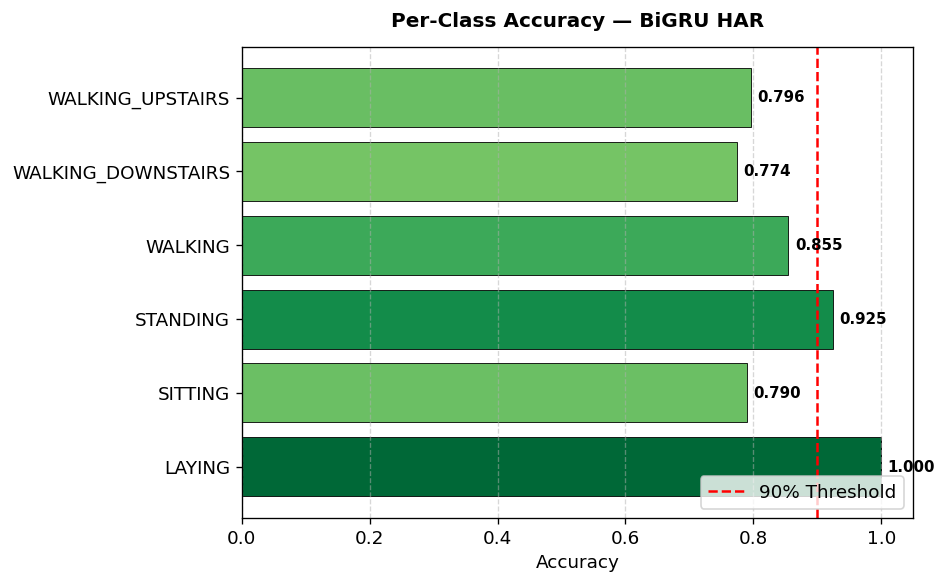

In [13]:
# 2. Per-Class Accuracy
plt.figure(figsize=(8, 5))

per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = plt.barh(class_labels, per_class_acc,
                color=plt.cm.RdYlGn(per_class_acc), edgecolor='black', linewidth=0.5)
plt.axvline(0.9, color='red', linestyle='--', lw=1.5, label='90% Threshold')

plt.title('Per-Class Accuracy — BiGRU HAR', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Accuracy')
plt.xlim(0, 1.05)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, per_class_acc):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()

# Lưu biểu đồ Per-Class Accuracy
plt.savefig(f'{SAVE_DIR}/04_b_per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Print the classification report
print(classification_report(y_true, y_pred, target_names=class_labels))

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.91      0.79      0.84       491
          STANDING       0.83      0.92      0.88       532
           WALKING       0.78      0.85      0.81       496
WALKING_DOWNSTAIRS       0.85      0.77      0.81       420
  WALKING_UPSTAIRS       0.82      0.80      0.81       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



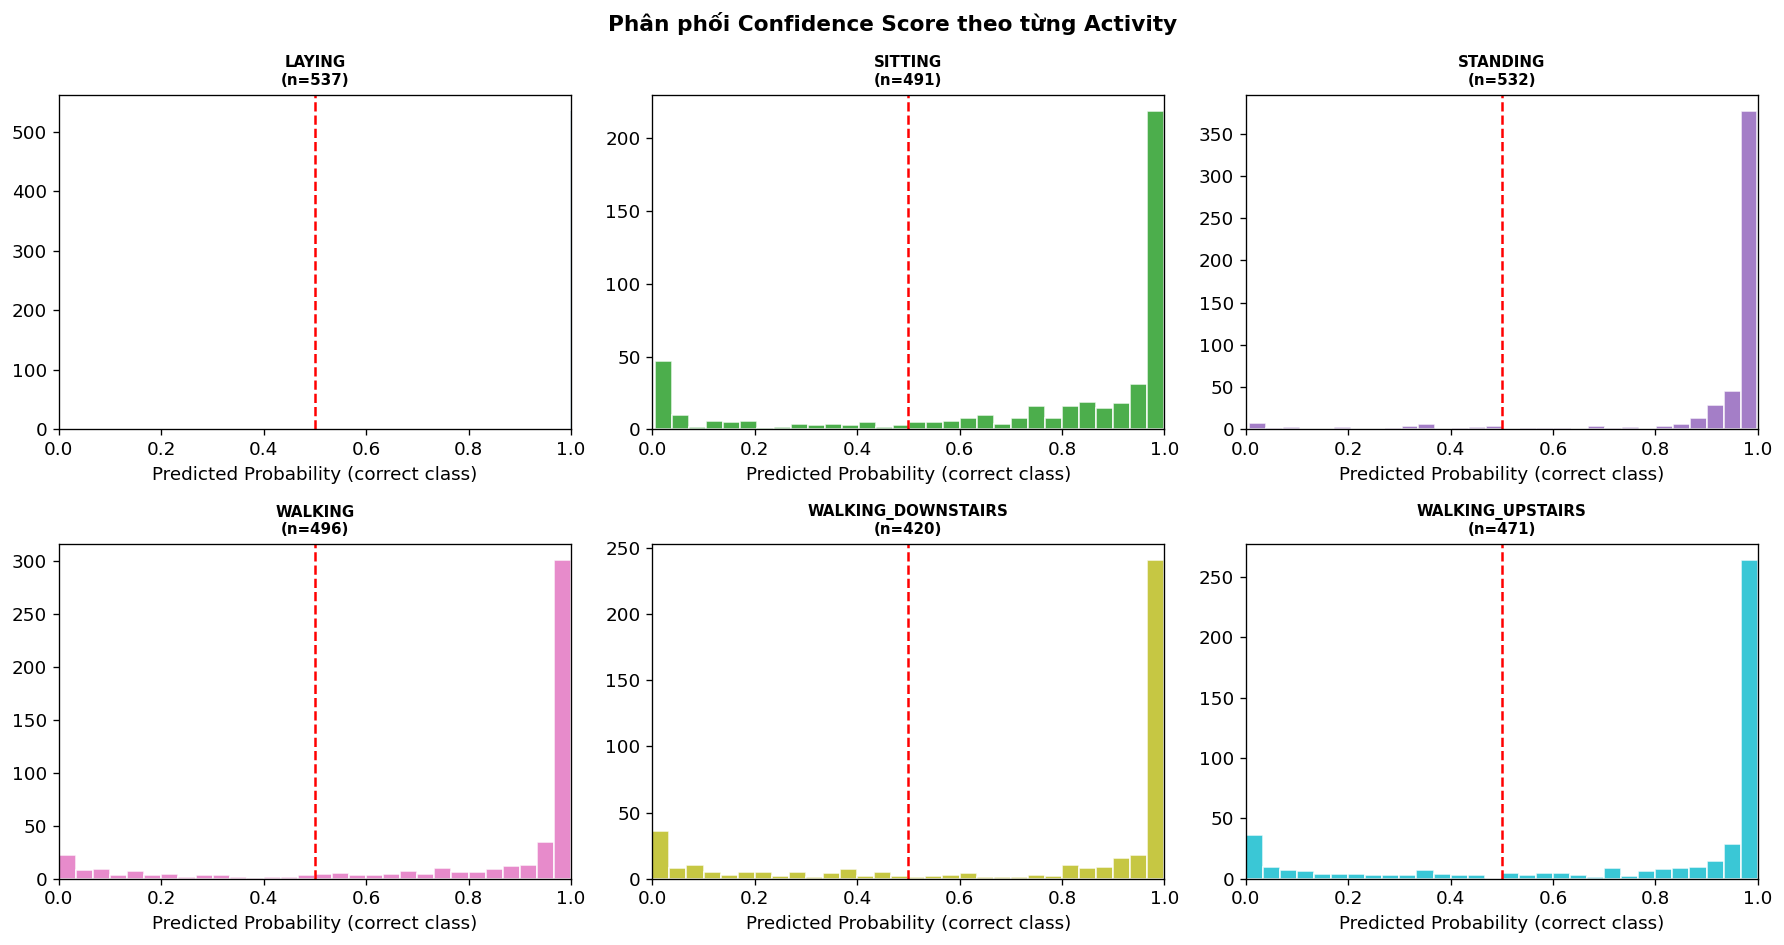

In [15]:
# Per-class probability confidence distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (lbl, name) in enumerate(zip(unique_labels, class_labels)):
    if i >= len(axes): break
    idx = np.where(y_true == lbl)[0]
    probs_correct_class = y_pred_prob[idx, lbl]
    axes[i].hist(probs_correct_class, bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(0.5, color='red', linestyle='--', lw=1.5)
    axes[i].set_title(f'{name}\n(n={len(idx):,})', fontsize=9)
    axes[i].set_xlabel('Predicted Probability (correct class)')
    axes[i].set_xlim(0, 1)

# Hide extra subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối Confidence Score theo từng Activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_confidence_distribution.png', bbox_inches='tight')
plt.show()

In [16]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('HAR Sensor Data — Bidirectional GRU\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write('Per-Class Accuracy:\n')
    for name, acc in zip(class_labels, per_class_acc):
        f.write(f'  {name:25s}: {acc:.4f}\n')
    f.write('\n' + classification_report(y_true, y_pred, target_names=class_labels))

print('✅ HAR BiGRU Experiment Done! Saved to', SAVE_DIR)

✅ HAR BiGRU Experiment Done! Saved to ../results/har_gru
